##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision import transforms

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)

model = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
model.eval()
model = model.to(device)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

Device: cuda
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 224MB/s]


In [6]:
# Exercise 1: Unsupervised Clustering

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
from torchvision import datasets, transforms
from torch.utils.data import Subset
from PIL import Image

# Transform for DINO/ViT model
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    )
])

# Load Oxford-IIIT Pet dataset
dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=transform
)

# Oxford Pets labels:
# Usually first 12 classes are cats, remaining classes are dogs
def get_pet_type(label):
    return 0 if label < 12 else 1   # 0 = Cat, 1 = Dog

# Select 10 cats and 10 dogs
cat_indices = []
dog_indices = []

for i in range(len(dataset)):
    _, label = dataset[i]
    if get_pet_type(label) == 0 and len(cat_indices) < 10:
        cat_indices.append(i)
    elif get_pet_type(label) == 1 and len(dog_indices) < 10:
        dog_indices.append(i)
    
    if len(cat_indices) == 10 and len(dog_indices) == 10:
        break

selected_indices = cat_indices + dog_indices

cls_tokens = []
true_labels = []
images_to_show = []

# Extract CLS tokens
model.eval()

with torch.no_grad():
    for idx in selected_indices:
        image, label = dataset[idx]
        true_labels.append(get_pet_type(label))
        images_to_show.append(image)

        image = image.unsqueeze(0).to(device)

        # Extract 384-dimensional CLS token
        features = model.forward_features(image)
        cls_token = features["x_norm_clstoken"]

        cls_tokens.append(cls_token.cpu().numpy().flatten())

cls_tokens = np.array(cls_tokens)
true_labels = np.array(true_labels)

print("CLS tokens shape:", cls_tokens.shape)
print("Ground truth labels:", true_labels)

CLS tokens shape: (20, 384)
Ground truth labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [7]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
pred_clusters = kmeans.fit_predict(cls_tokens)

print("Predicted clusters:", pred_clusters)

Predicted clusters: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [8]:
# Since KMeans cluster numbers are arbitrary, check both mappings

acc1 = accuracy_score(true_labels, pred_clusters)
acc2 = accuracy_score(true_labels, 1 - pred_clusters)

if acc2 > acc1:
    pred_labels = 1 - pred_clusters
    accuracy = acc2
else:
    pred_labels = pred_clusters
    accuracy = acc1

print("True labels:     ", true_labels)
print("Predicted labels:", pred_labels)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

True labels:      [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Predicted labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Accuracy: 1.0

Confusion Matrix:
[[10  0]
 [ 0 10]]


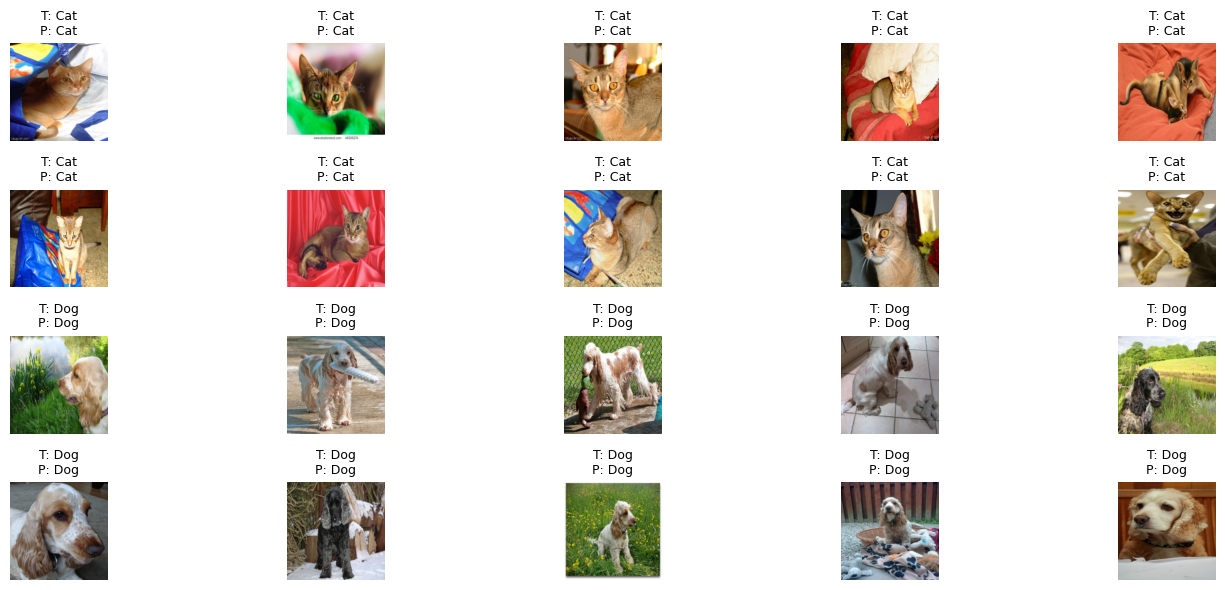

In [9]:
# Show selected images with predicted cluster labels

plt.figure(figsize=(15, 6))

for i, img in enumerate(images_to_show):
    img = img.permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

    true_name = "Cat" if true_labels[i] == 0 else "Dog"
    pred_name = "Cat" if pred_labels[i] == 0 else "Dog"

    plt.title(f"T: {true_name}\nP: {pred_name}", fontsize=9)

plt.tight_layout()
plt.show()

The K-Means clustering result shows that the DINOv2 CLS tokens successfully separated the 20 pet images into two groups: cats and dogs. The CLS token matrix has a shape of (20, 384), meaning that 20 images were represented using 384-dimensional feature vectors. After applying K-Means with n_clusters=2, the predicted clusters matched the ground-truth labels perfectly, achieving an accuracy of 1.0. The confusion matrix shows that all 10 cat images and all 10 dog images were classified into the correct clusters.

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [10]:
# Provide your solution here
!pip install transformers pillow -q

import torch
from PIL import Image
import requests
from transformers import AutoImageProcessor, AutoModelForImageClassification

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id).to(device)
model.eval()

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/91.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Dinov2ForImageClassification(
  (dinov2): Dinov2Model(
    (embeddings): Dinov2Embeddings(
      (patch_embeddings): Dinov2PatchEmbeddings(
        (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): Dinov2Encoder(
      (layer): ModuleList(
        (0-11): 12 x Dinov2Layer(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attention): Dinov2Attention(
            (attention): Dinov2SelfAttention(
              (query): Linear(in_features=384, out_features=384, bias=True)
              (key): Linear(in_features=384, out_features=384, bias=True)
              (value): Linear(in_features=384, out_features=384, bias=True)
            )
            (output): Dinov2SelfOutput(
              (dense): Linear(in_features=384, out_features=384, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (layer_scale1): Dinov2Laye

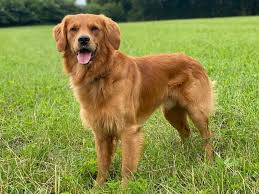

In [12]:
image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSKlY5giO4e0_exXFNHferEr9_WG_FuKoPHPA&s"

image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")
image

In [13]:
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class_id = logits.argmax(-1).item()

predicted_label = model.config.id2label[predicted_class_id]

print("Predicted class ID:", predicted_class_id)
print("Predicted label:", predicted_label)

Predicted class ID: 207
Predicted label: golden retriever


In [14]:
probs = torch.nn.functional.softmax(logits, dim=-1)
top5 = torch.topk(probs, k=5)

for i in range(5):
    class_id = top5.indices[0][i].item()
    score = top5.values[0][i].item()
    label = model.config.id2label[class_id]
    print(f"{i+1}. {label}: {score:.4f}")

1. golden retriever: 0.9282
2. curly-coated retriever: 0.0121
3. Leonberg: 0.0079
4. Sussex spaniel: 0.0077
5. Irish setter, red setter: 0.0064


In this exercise, the DINOv2 model with a pre-trained ImageNet-1k linear classification head was used to classify an online image. The image was first preprocessed using the matching image processor, then passed through the model to obtain logits for the 1000 ImageNet classes. The class with the highest logit value was selected as the final prediction. The top-5 predictions show the categories with the highest confidence scores.